In [ ]:
# Import libraries for K-mean model
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy.stats import mode

In [18]:
# K-mean model training

# Load data from models folder (Matrix)
X = np.load("../models/X_features.npy")
y_raw = np.load("../models/y_labels.npy", allow_pickle=True)

# Take the album and translate them into number (0 and 1)
with open("../models/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)
y_true = le.transform(y_raw)
# Separate the data into 2 groups "Spam" and "Ham"
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Calculate the Silhouette score
sil_score = silhouette_score(X, clusters)
print(f"Silhouette score: {sil_score:.4f}")

# Clustering to see the accuracy
predicted_labels = np.zeros_like(clusters)
for i in range(2):
    mask = (clusters == i)
    # Find the most common label in the group then label the group with it
    predicted_labels[mask] = mode(y_true[mask], keepdims=True)[0][0]

print(f" Accuracy : {accuracy_score(y_true, predicted_labels) * 100:.2f}%")

# Save the model into models folder
with open("../models/kmeans_model.pkl", "wb") as f: 
    pickle.dump(kmeans, f)
print("Saved in to models")

Silhouette score: 0.4587
 Accuracy : 85.00%
Saved in to models


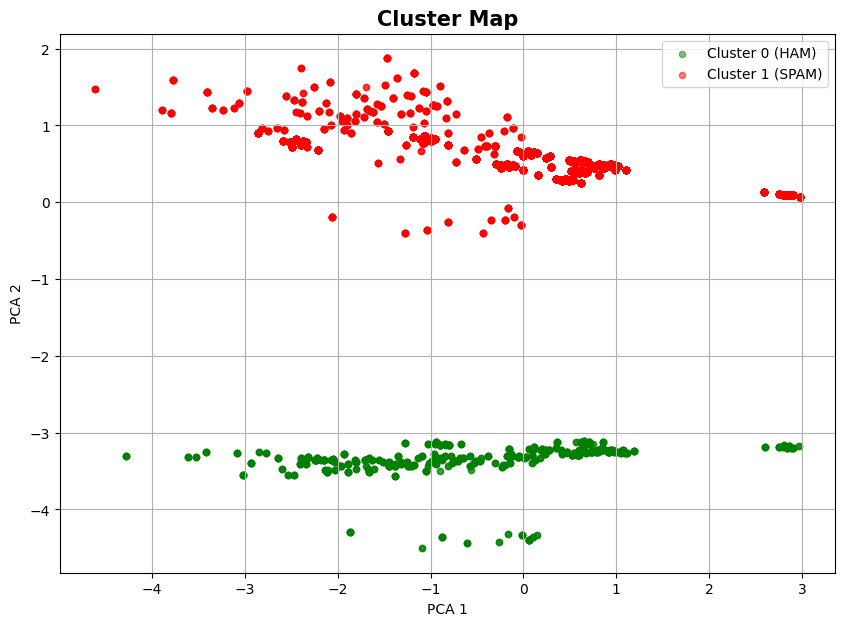

In [19]:
# Plot the clustered data

# Use PCA to compress the big data into X and Y axis to plot 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Plotting
plt.figure(figsize=(10, 7))

# Take the HAM cluster and color it blue
plt.scatter(X_pca[clusters == 0, 0], X_pca[clusters == 0, 1], 
            label='Cluster 0 (HAM)', color='green', alpha=0.5, s=20)

# Take the SPAM Cluster and color it red 
plt.scatter(X_pca[clusters == 1, 0], X_pca[clusters == 1, 1], 
            label='Cluster 1 (SPAM)', color='red', alpha=0.5, s=20)

plt.title('Cluster Map', fontsize=15, fontweight='bold')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

  K-MEANS EVALUATION RESULTS
Accuracy:  0.8500 (85.00%)
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
Silhouette: 0.4587
------------------------------


c:\Users\12a5n\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


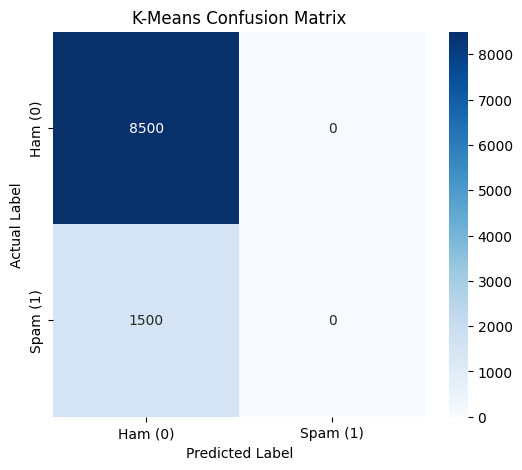


 Summary Table:
          Metric  Value
        Accuracy 85.00%
       Precision 0.0000
          Recall 0.0000
        F1-Score 0.0000
Silhouette Score 0.4587


In [ ]:
y_true_int = y_true.astype(int)
y_pred_int = predicted_labels.astype(int)

# Calculate indexes
acc = accuracy_score(y_true_int, y_pred_int)
pre = precision_score(y_true_int, y_pred_int)
rec = recall_score(y_true_int, y_pred_int)
f1  = f1_score(y_true_int, y_pred_int)


print("="*30)
print("  K-MEANS EVALUATION RESULTS")
print("="*30)
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Silhouette: {sil_score:.4f}")
print("-" * 30)

#Confusion Matrix 
cm = confusion_matrix(y_true_int, y_pred_int)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('K-Means Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Summary Table 
summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Silhouette Score'],
    'Value': [f"{acc*100:.2f}%", f"{pre:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{sil_score:.4f}"]
})
print("\n Summary Table:")
print(summary_df.to_string(index=False))